<p style="font-size:16px; line-height:1.6;">
<b>Project:</b> Credit Risk Prediction and Default Analysis<br>
<b>Name:</b> Aneel Hassan<br>
<b>Submitted to:</b> Sir Hassan Raza<br>
<b>Subject:</b> Machine Learning<br>
<b>Program:</b> BSBI<br>
<b>Semester:</b> 5th
</p>

<p style="font-size:22px;"><b>Import Libraries</b></p>

In [31]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

<p style="font-size:22px;"><b>Load Dataset</b></p>

In [32]:
# LOAD DATASET
df = pd.read_csv('credit.csv')

<p style="font-size:22px;"><b>Basic EDA & Preprocessing</b></p>

In [33]:
df.head()

,observation_id,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,...,age,installment_plan,housing,existing_credits,default,dependents,telephone,foreign_worker,job,gender
0,0,-43.0,6,critical,radio/tv,1169,NaN,13 years,4,single,...,67,none,own,2,0,1,2.349340e+09,yes,skilled employee,male
1,1,75.0,48,repaid,radio/tv,5951,89.0,2 years,2,NaN,...,22,none,own,1,1,1,NaN,yes,skilled employee,female
2,2,NaN,12,critical,education,2096,24.0,5 years,2,single,...,49,none,own,1,0,2,NaN,yes,unskilled resident,male
3,3,-32.0,42,repaid,furniture,7882,9.0,5 years,2,single,...,45,none,for free,1,0,2,NaN,yes,skilled employee,male
4,4,-23.0,24,delayed,car (new),4870,43.0,3 years,3,single,...,53,none,for free,2,1,2,NaN,yes,skilled employee,male


In [34]:
df.info

<bound method DataFrame.info of      observation_id  checking_balance  months_loan_duration credit_history  \
0                 0             -43.0                     6       critical   
1                 1              75.0                    48         repaid   
2                 2               NaN                    12       critical   
3                 3             -32.0                    42         repaid   
4                 4             -23.0                    24        delayed   
..              ...               ...                   ...            ...   
995             995               NaN                    12         repaid   
996             996             -30.0                    30         repaid   
997             997               NaN                    12         repaid   
998             998             -18.0                    45         repaid   
999             999             194.0                    45       critical   

        purpose  amount  saving

In [35]:
df.describe()

,observation_id,checking_balance,months_loan_duration,amount,savings_balance,installment_rate,age,existing_credits,default,dependents,telephone
count,1000.000000,606.000000,1000.000000,1000.000000,817.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,4.040000e+02
mean,499.500000,97.245875,20.903000,3271.258000,781.570379,2.973000,35.546000,1.407000,0.300000,1.155000,2.344914e+09
std,288.819436,206.923583,12.058814,2822.736876,3016.983785,1.118715,11.375469,0.577654,0.458487,0.362086,3.008193e+06
min,0.000000,-50.000000,4.000000,250.000000,0.000000,1.000000,19.000000,1.000000,0.000000,1.000000,2.340000e+09
25%,249.750000,-23.000000,12.000000,1365.500000,31.000000,2.000000,27.000000,1.000000,0.000000,1.000000,2.342211e+09
50%,499.500000,24.000000,18.000000,2319.500000,64.000000,3.000000,33.000000,1.000000,0.000000,1.000000,2.344804e+09
75%,749.250000,131.750000,24.000000,3972.250000,128.000000,4.000000,42.000000,2.000000,1.000000,1.000000,2.347731e+09
max,999.000000,999.000000,72.000000,18424.000000,19972.000000,4.000000,75.000000,4.000000,1.000000,2.000000,2.349994e+09


In [36]:
df.isnull().sum()

observation_id            0
checking_balance        394
months_loan_duration      0
credit_history            0
purpose                   0
amount                    0
savings_balance         183
employment_length        62
installment_rate          0
personal_status         310
other_debtors             0
residence_history       130
property                  0
age                       0
installment_plan          0
housing                   0
existing_credits          0
default                   0
dependents                0
telephone               596
foreign_worker            0
job                       0
gender                    0
dtype: int64

In [37]:
df = df.drop(columns=['observation_id', 'telephone'])


def convert_to_years(val):
    if pd.isna(val): return np.nan
    val = str(val).lower()
    if 'year' in val: return float(val.split()[0])
    elif 'month' in val: return float(val.split()[0]) / 12
    return np.nan

df['employment_length'] = df['employment_length'].apply(convert_to_years)
df['residence_history'] = df['residence_history'].apply(convert_to_years)

for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])


df_encoded = pd.get_dummies(df, drop_first=True)

 
X = df_encoded.drop('default', axis=1)
y = df_encoded['default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=19, stratify=y)



def plot_confusion_matrix(y_true, y_pred, title, color='Blues'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=color)
    plt.title(f'Confusion Matrix: {title}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

<p style="font-size:22px;"><b>Define Features & Target</b></p>

In [38]:
X = df_encoded.drop('default', axis=1)
y = df_encoded['default']

<p style="font-size:22px;"><b>Feature Scaling</b></p>

In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [40]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

<p style="font-size:22px;"><b>Evaluation</b></p>

In [41]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest (Base)": accuracy_score(y_test, y_pred_rf_base),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "Random Forest": accuracy_score(y_test, y_pred_opt)
}

print("\n--- MODEL PERFORMANCE SUMMARY ---")
for model, acc in results.items():
    print(f"{model} Accuracy: {acc:.4f}")

best_model_name = max(results, key=results.get)
print(f"\nFinal Classification: The best model is {best_model_name}")
print(classification_report(y_test, y_pred_opt))


--- MODEL PERFORMANCE SUMMARY ---
Logistic Regression Accuracy: 0.5000
Decision Tree Accuracy: 0.7100
Random Forest (Base) Accuracy: 0.7500
SVM Accuracy: 0.5300
Random Forest Accuracy: 0.7600

Final Classification: The best model is Random Forest
              precision    recall  f1-score   support

           0       0.76      0.97      0.85       141
           1       0.79      0.25      0.38        59

    accuracy                           0.76       200
   macro avg       0.77      0.61      0.62       200
weighted avg       0.77      0.76      0.71       200



<p style="font-size:22px;"><b>Model Confusion Matrix Charts</b></p>


---  Random Forest  ---


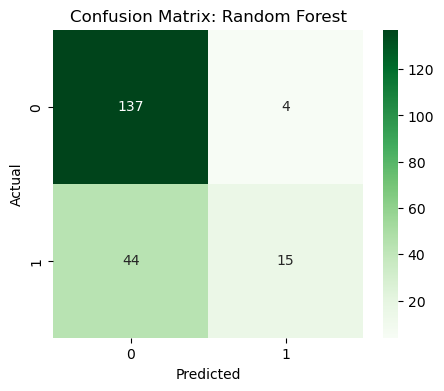

In [42]:
rf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=12, 
    min_samples_split=5, 
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_opt = rf.predict(X_test)
print("\n---  Random Forest  ---")
plot_confusion_matrix(y_test, y_pred_opt, "Random Forest", color='Greens')